# Classwise evaluation for the experiments with the synthetic interviews

Loading the ML-Flow data

In [1]:
import mlflow
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator
import math

with open("/path/mlflow.json", 'r') as file:
    data = json.load(file)
    os.environ['MLFLOW_TRACKING_USERNAME'] = data["MLFLOW_TRACKING_USERNAME"]
    os.environ['MLFLOW_TRACKING_PASSWORD'] = data["MLFLOW_TRACKING_PASSWORD"]

mlflow.set_tracking_uri("ml_flow_path")

EXPERIMENT_NAME = "setfit_silicon_interviews_ext3"
METRIC_COL = "metrics.macro_avg_f1"

exp = mlflow.get_experiment_by_name(EXPERIMENT_NAME)
runs = mlflow.search_runs(
    experiment_ids=[exp.experiment_id],
    output_format="pandas"
)

# Parent runs (model configs)
parents = runs[runs["tags.mlflow.parentRunId"].isna()].copy()

# Iteration runs (nested)
children = runs[runs["tags.mlflow.parentRunId"].notna()].copy()

In [2]:
# Keep only what we need from parents
parents_small = parents[
    [
        "run_id",
        "tags.mlflow.runName",
        "params.model_name",
        "params.query_strategy",
        "params.clf_factory.classification_kwargs.use_differentiable_head",
        "params.end_to_end",
    ]
].rename(columns={"run_id": "parent_run_id"})

df = children.merge(
    parents_small,
    left_on="tags.mlflow.parentRunId",
    right_on="parent_run_id",
    how="left"
)

df["iteration"] = df["params.iteration"].astype(int)
df["f1"] = df[METRIC_COL]

df = df.dropna(subset=["f1"])

In [3]:
AGG_METRIC = "metrics.macro_avg_f1"

# Convert the column to actual boolean
df["params.clf_factory.classification_kwargs.use_differentiable_head"] = \
    df["params.clf_factory.classification_kwargs.use_differentiable_head_y"].map(
        lambda x: True if str(x).lower() == "true" else False
    )

# Then create head_type
df["head_type"] = df[
    "params.clf_factory.classification_kwargs.use_differentiable_head"
].map({True: "Differentiable head", False: "Logit head"})


df["f1"] = df[AGG_METRIC]
df["model_config"] = df["tags.mlflow.runName_y"]

diff_df = df[df["head_type"] == "Differentiable head"]
logit_df = df[df["head_type"] != "Differentiable head"]

Helper

In [5]:
def shorten_name(full_name):
    # Shorten only the base model (first part before __), keep the rest
    parts = full_name.split("__")
    base = parts[0].replace("setfit_multilingual-", "setfit_ml-").replace("setfit_paraphrase-multilingual", "setfit_paraphrase-ml")
    parts[-1] = parts[-1].replace("PredictionEntropy", "PE").replace("CategoryVectorInconsistencyAndRanking", "CVIAR")
    return "|".join([base] + parts[1:])

In [4]:
codes_health = ["physical_health", "mental_health", "daily_functioning", "health_unspecific", "health_none"]
codes_freq = ["freq_mentioned", "freq_not_mentioned"]
codes_neg = ["health_none", "freq_not_mentioned"]

codes_combined = codes_health + codes_freq
code_full = {label: idx for idx, label in enumerate(codes_combined)}
code_pos = {k: v for k, v in code_full.items() if k not in codes_neg}
code_neg = {k: v for k, v in code_full.items() if k in codes_neg}
code_pos_new = {k: i for k, i in enumerate(code_pos.keys())}

In [6]:
line_styles = ["-", "--", "-.", ":"]
markers = ["o", "s", "D", "^", "v", "<", ">", "P", "X", "*", "h", "8"]

## F1-Scores across models for each class

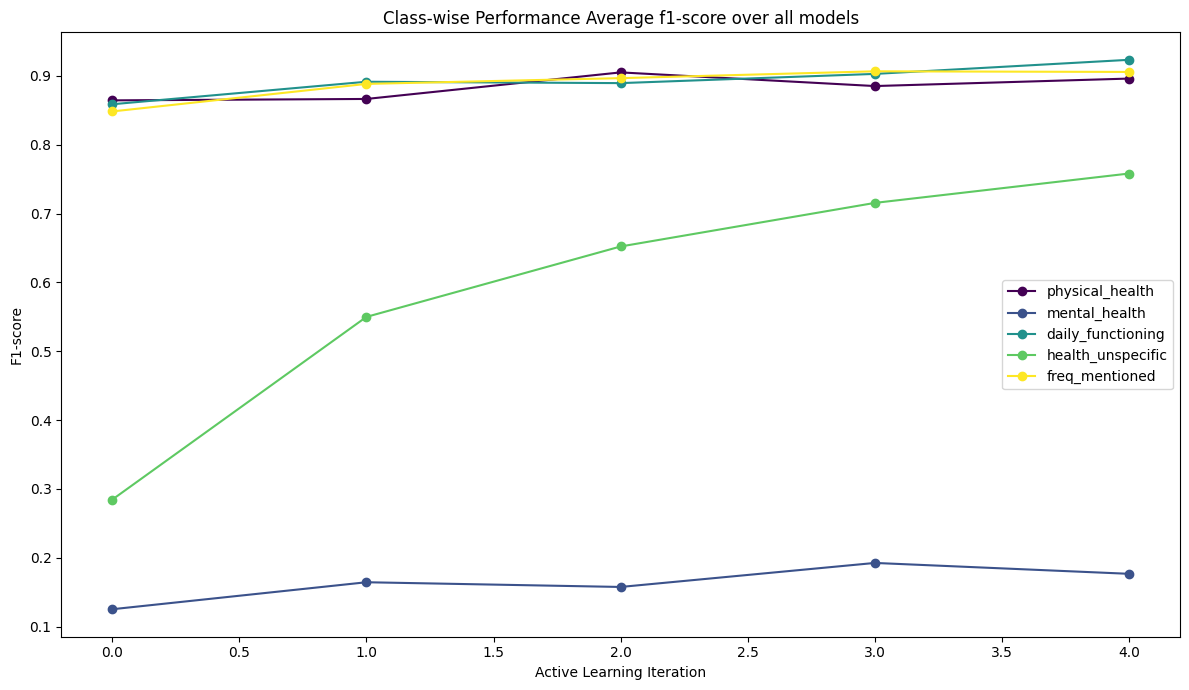

In [7]:
class_f1_cols = [
    c for c in df.columns
    if c.startswith("metrics.") and c.split(".")[1].split("_")[0].isdigit() and c.endswith("_f1-score")
]

class_f1_cols = sorted(class_f1_cols, key=lambda x: int(x.split(".")[1].split("_")[0]))

colors = plt.cm.viridis(np.linspace(0, 1, len(class_f1_cols)))

plt.figure(figsize=(12, 7))

for i, col in enumerate(class_f1_cols):
    class_id = col.split(".")[1].split("_")[0]
    mean_curve = (
        logit_df.groupby("iteration")[col]
        .mean()
        .sort_index()
    )
    plt.plot(mean_curve.index, 
             mean_curve.values, 
             marker="o", 
             color=colors[i],
             label=code_pos_new[i])

plt.xlabel("Active Learning Iteration")
plt.ylabel("F1-score")
plt.title("Class-wise Performance Average f1-score over all models")
plt.legend()
plt.tight_layout()
plt.savefig("results/logit_classwise_f1.png")

## F-1 Scores for the different model configurations for each class

### Configurations with logit head

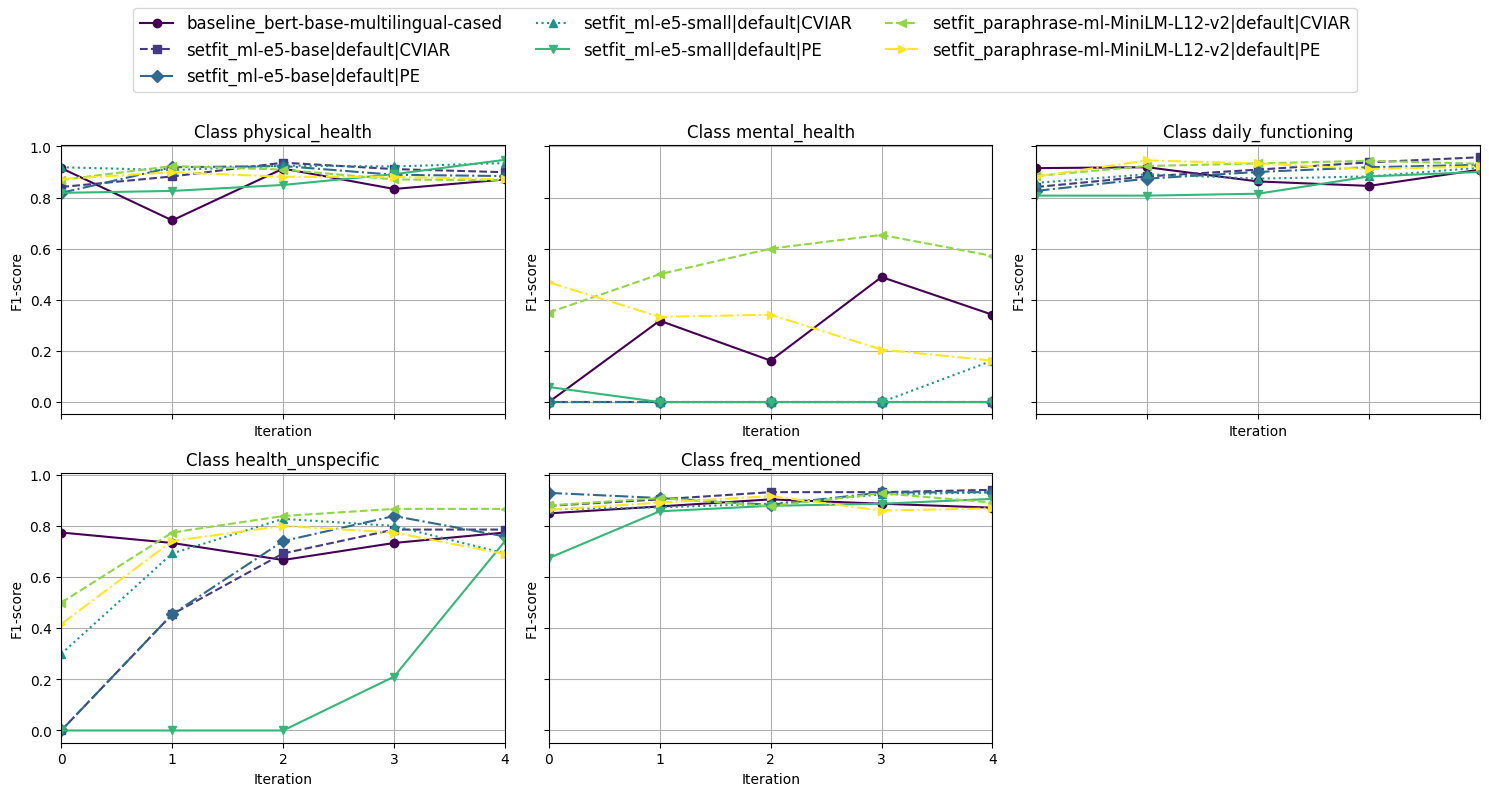

In [8]:
# number of classes
num_classes = len(class_f1_cols)
configs = logit_df["model_config"].unique()
n_configs = len(configs)
colors = plt.cm.viridis(np.linspace(0, 1, n_configs))

xmin = logit_df["iteration"].min()
xmax = logit_df["iteration"].max()

# Grid layout (adjust to your taste)
cols = 3
rows = math.ceil(num_classes / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), sharex=True, sharey=True)
axes = axes.flatten()  # flatten in case grid is not square

for i, col in enumerate(class_f1_cols):
    ax = axes[i]
    class_id = int(col.split(".")[1].split("_")[0])
    
    for j, (model_name, g) in enumerate(logit_df.groupby("model_config")):
        g = g.sort_values("iteration")
        ax.plot(
            g["iteration"],
            g[col],
            linestyle=line_styles[j % len(line_styles)],
            marker=markers[j % len(markers)],
            color=colors[j],
            label=shorten_name(model_name)
        )
    ax.set_title(f"Class {code_pos_new.get(class_id)}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("F1-score")
    ax.grid(True)

# Remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Force integer x-axis
for ax in axes:
    ax.set_xlim(xmin, xmax)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.subplots_adjust(top=0.82)

# Shared legend outside the grid
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=12)

plt.savefig("results/logit_classwise_f1_grid.png")

### Configurations with differentiable head

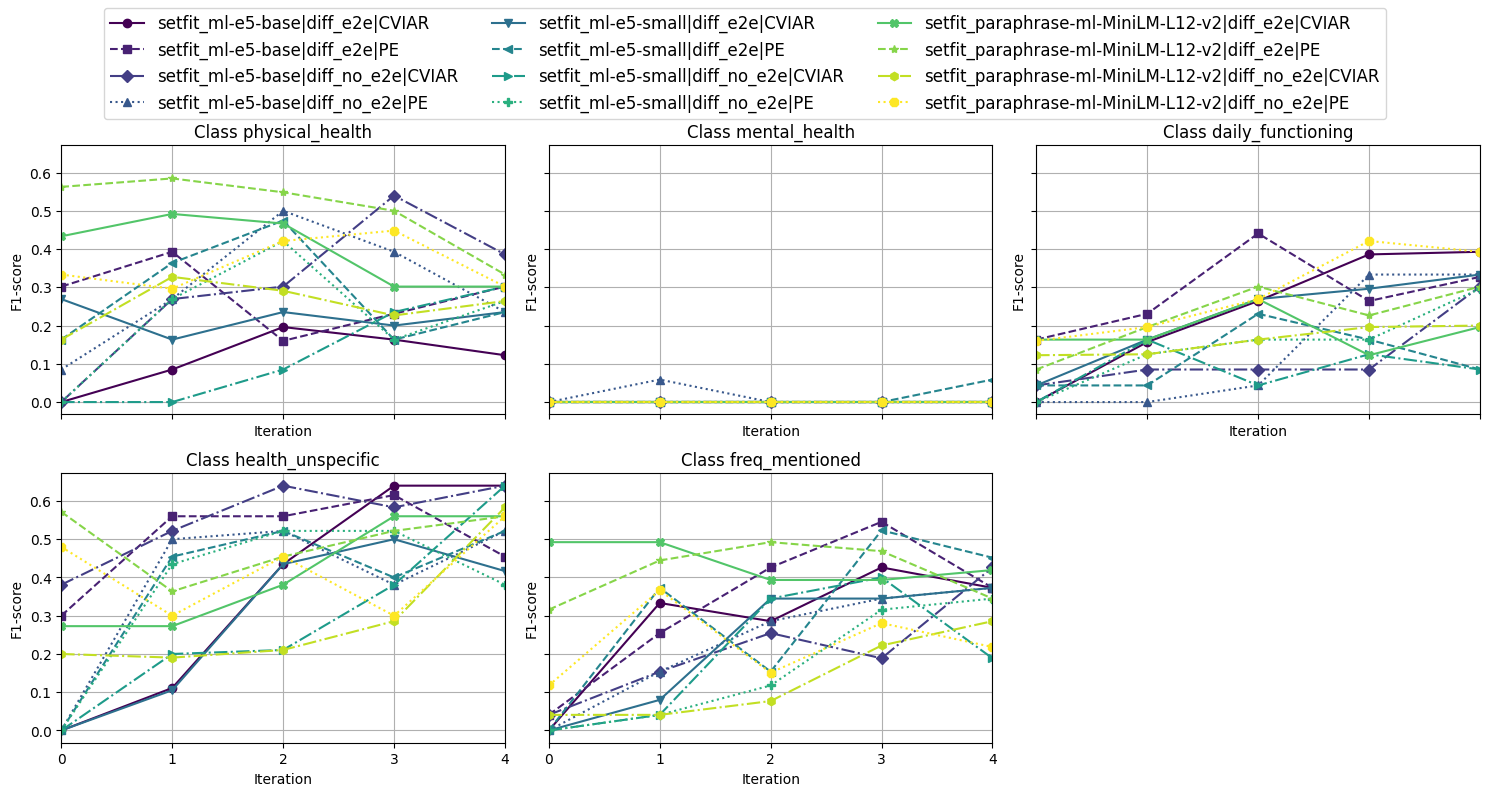

In [9]:
num_classes = len(class_f1_cols)
configs = diff_df["model_config"].unique()
n_configs = len(configs)
colors = plt.cm.viridis(np.linspace(0, 1, n_configs))

xmin = diff_df["iteration"].min()
xmax = diff_df["iteration"].max()

# Grid layout (adjust to your taste)
cols = 3
rows = math.ceil(num_classes / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), sharex=True, sharey=True)
axes = axes.flatten()  # flatten in case grid is not square

for i, col in enumerate(class_f1_cols):
    ax = axes[i]
    class_id = int(col.split(".")[1].split("_")[0])
    
    for j, (model_name, g) in enumerate(diff_df.groupby("model_config")):
        g = g.sort_values("iteration")
        ax.plot(
            g["iteration"],
            g[col],
            linestyle=line_styles[j % len(line_styles)],
            marker=markers[j % len(markers)],
            color=colors[j],
            label=shorten_name(model_name)
        )
    ax.set_title(f"Class {code_pos_new.get(class_id)}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("F1-score")
    ax.grid(True)

# Remove empty subplots if any
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

# Force integer x-axis
for ax in axes:
    ax.set_xlim(xmin, xmax)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout(rect=[0, 0, 1, 0.9])
plt.subplots_adjust(top=0.82)

# Shared legend outside the grid
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, fontsize=12)

plt.savefig("results/diff_classwise_f1_grid.png")

## Comparison of recall and precision for different configuration types and classes

### Configurations with logit head

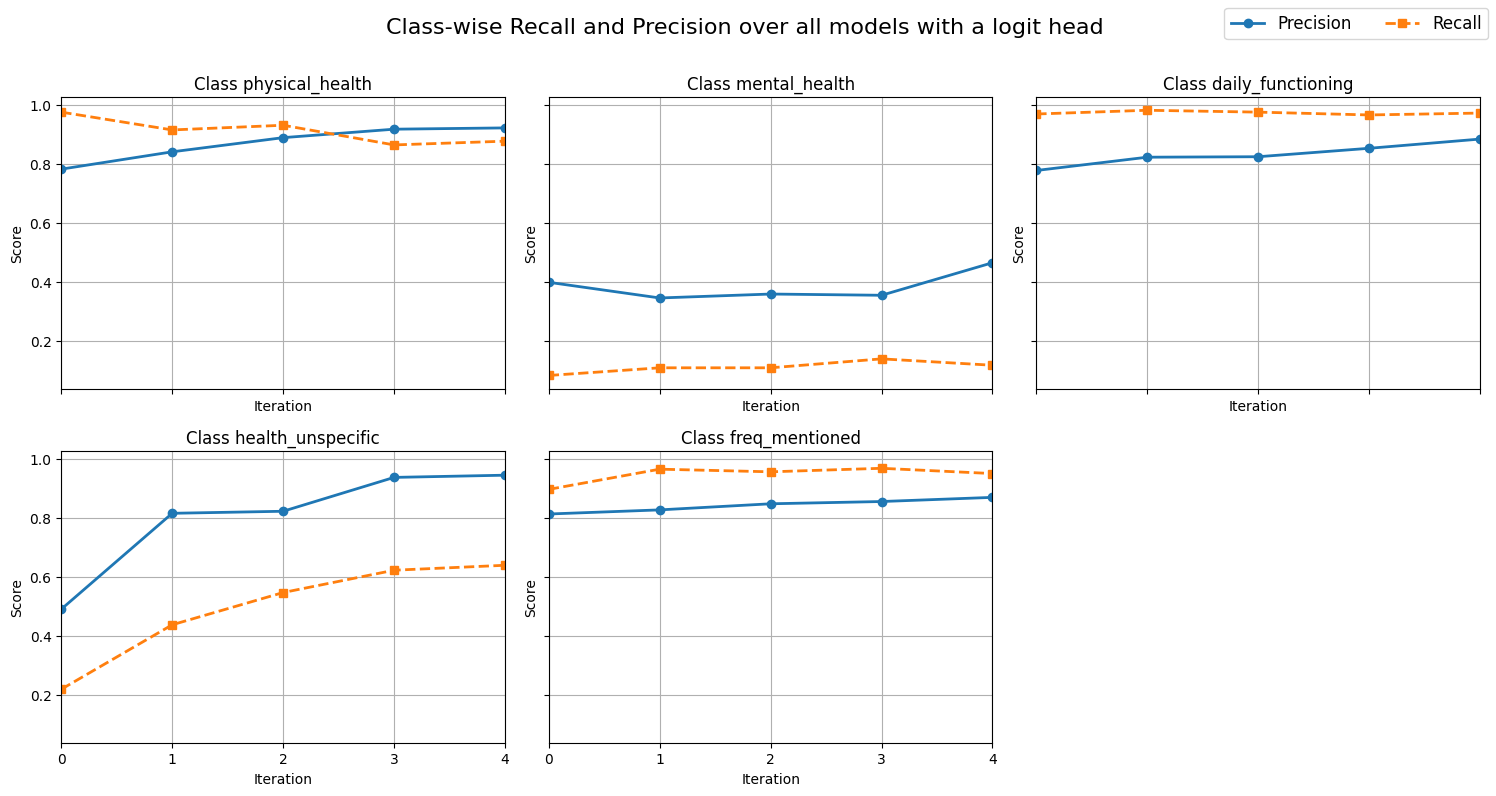

In [107]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def get_class_metric_cols(df, metric):
    return [
        c for c in df.columns
        if c.startswith("metrics.")
        and c.endswith(f"_{metric}")
        and c.split(".")[1].split("_")[0].isdigit()
    ]

# get columns
precision_cols = get_class_metric_cols(logit_df, "precision")
recall_cols = get_class_metric_cols(logit_df, "recall")

# map class_id -> column
precision_map = {
    int(c.split(".")[1].split("_")[0]): c for c in precision_cols
}
recall_map = {
    int(c.split(".")[1].split("_")[0]): c for c in recall_cols
}

class_ids = sorted(precision_map.keys())

xmin = logit_df["iteration"].min()
xmax = logit_df["iteration"].max()

cols = 3
rows = math.ceil(len(class_ids) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, class_id in enumerate(class_ids):

    ax = axes[i]
    class_name = code_pos_new.get(class_id, class_id)

    p_col = precision_map[class_id]
    r_col = recall_map[class_id]

    avg = (
        logit_df.groupby("iteration")[[p_col, r_col]]
        .mean()
        .reset_index()
        .sort_values("iteration")
    )

    # Precision
    ax.plot(
        avg["iteration"],
        avg[p_col],
        marker="o",
        linestyle="-",
        linewidth=2,
        label="Precision"
    )

    # Recall
    ax.plot(
        avg["iteration"],
        avg[r_col],
        marker="s",
        linestyle="--",
        linewidth=2,
        label="Recall"
    )

    ax.set_title(f"Class {class_name}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Score")
    ax.grid(True)

# remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# force integer x-axis
for ax in axes:
    ax.set_xlim(xmin, xmax)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=2, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.subplots_adjust(top=0.88)

fig.suptitle("Class-wise Recall and Precision over all models with a logit head", fontsize=16)
# save
plt.savefig("results/logit_classwise_precision_recall_avg.png")

# show in notebook
plt.show()

### Configurations with differentiable head

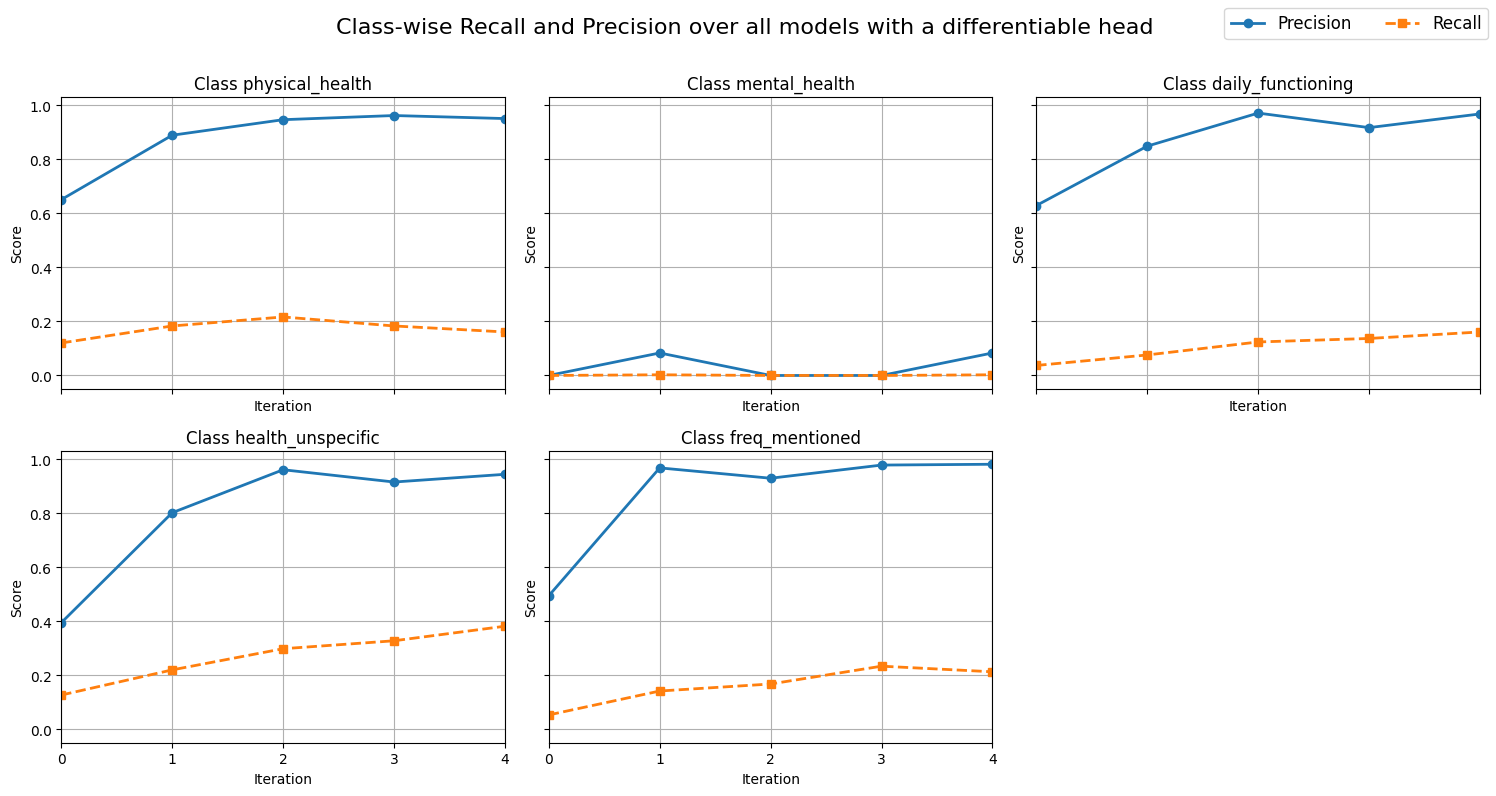

In [108]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

def get_class_metric_cols(df, metric):
    return [
        c for c in df.columns
        if c.startswith("metrics.")
        and c.endswith(f"_{metric}")
        and c.split(".")[1].split("_")[0].isdigit()
    ]

# get columns
precision_cols = get_class_metric_cols(diff_df, "precision")
recall_cols = get_class_metric_cols(diff_df, "recall")

# map class_id -> column
precision_map = {
    int(c.split(".")[1].split("_")[0]): c for c in precision_cols
}
recall_map = {
    int(c.split(".")[1].split("_")[0]): c for c in recall_cols
}

class_ids = sorted(precision_map.keys())

xmin = diff_df["iteration"].min()
xmax = diff_df["iteration"].max()

cols = 3
rows = math.ceil(len(class_ids) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, class_id in enumerate(class_ids):

    ax = axes[i]
    class_name = code_pos_new.get(class_id, class_id)

    p_col = precision_map[class_id]
    r_col = recall_map[class_id]

    avg = (
        diff_df.groupby("iteration")[[p_col, r_col]]
        .mean()
        .reset_index()
        .sort_values("iteration")
    )

    # Precision
    ax.plot(
        avg["iteration"],
        avg[p_col],
        marker="o",
        linestyle="-",
        linewidth=2,
        label="Precision"
    )

    # Recall
    ax.plot(
        avg["iteration"],
        avg[r_col],
        marker="s",
        linestyle="--",
        linewidth=2,
        label="Recall"
    )

    ax.set_title(f"Class {class_name}")
    ax.set_xlabel("Iteration")
    ax.set_ylabel("Score")
    ax.grid(True)

# remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# force integer x-axis
for ax in axes:
    ax.set_xlim(xmin, xmax)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=2, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.subplots_adjust(top=0.88)

fig.suptitle("Class-wise Recall and Precision over all models with a differentiable head", fontsize=16)


# save
plt.savefig("results/logit_classwise_precision_recall_avg.png")

# show in notebook
plt.show()

# optional: close to free memory
plt.close()

## ROC curve for selected configurations

Requires loading prediction probabilites from run artifacts and the used test data.

In [51]:
import pickle
import tempfile
from sklearn.metrics import average_precision_score
from mlflow.tracking import MlflowClient
from small_text import list_to_csr
import re

Only selected runs: Best overall, best run for the bert base model, and the best run out of the ones with differentiable head.

In [54]:
test_df = pd.read_pickle("data/test_df_new_interviews.pkl")
test_df  = test_df[test_df['peter'].notna()]

LABEL_COL = "peter"  # adjust if needed

# number of classes
NUM_CLASSES = len(class_f1_cols)

# convert to multilabel matrix (IMPORTANT)
y_true_matrix = list_to_csr(
    list(test_df[LABEL_COL].tolist()),
    shape=(len(test_df), NUM_CLASSES)
).toarray()

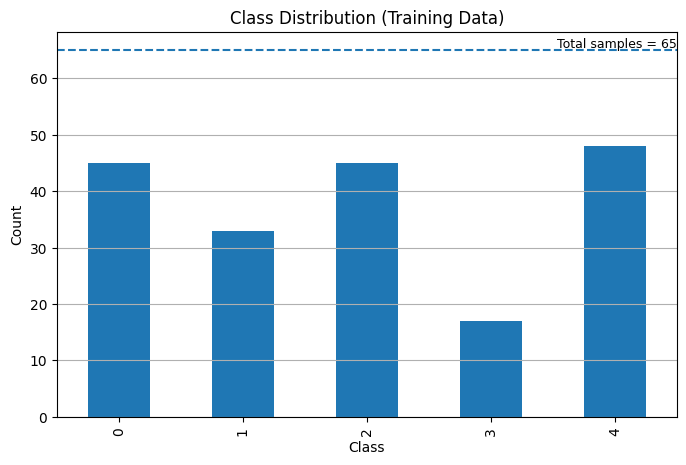

In [101]:
from collections import Counter

# flatten list of labels
all_labels = [label for labels in test_df[LABEL_COL] for label in labels]

# count occurrences
label_counts = Counter(all_labels)

# convert to dataframe
label_dist_df = pd.DataFrame.from_dict(label_counts, orient="index", columns=["count"])
label_dist_df = label_dist_df.sort_index()

# total number of examples
total_samples = len(test_df)

# plot
plt.figure(figsize=(8, 5))
label_dist_df["count"].plot(kind="bar")
plt.title("Class Distribution (Training Data)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.axhline(y=total_samples, linestyle="--")
plt.grid(axis="y")

plt.text(
    x=len(label_dist_df) - 0.5,
    y=total_samples,
    s=f"Total samples = {total_samples}",
    va="bottom",
    ha="right",
    fontsize=9
)

plt.show()

In [52]:
# Best performing run overall
best_run = df.loc[df["f1"].idxmax()]
# best bert run
best_bert_run = df[df['model_config'] == 'baseline_bert-base-multilingual-cased'].sort_values("f1", ascending=False).iloc[0]
# best diff head run
best_diff_head_run = df[df["head_type"] == "Differentiable head"].loc[diff_head_df["f1"].idxmax()]

relevant_runs = pd.DataFrame([best_run, best_bert_run, best_diff_head_run])

In [53]:
relevant_runs

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.micro avg_precision,metrics.micro avg_recall,metrics.macro_avg_f1,metrics.weighted avg_f1-score,...,tags.mlflow.runName_y,params.model_name_y,params.query_strategy_y,params.clf_factory.classification_kwargs.use_differentiable_head_y,params.end_to_end_y,iteration,f1,params.clf_factory.classification_kwargs.use_differentiable_head,head_type,model_config
36,5915e6e07d66468db03c557f32ac4739,19,FINISHED,mlflow-artifacts:/19/5915e6e07d66468db03c557f3...,2026-01-07 15:51:20.713000+00:00,2026-01-07 15:51:46.807000+00:00,0.933333,0.819149,0.852551,0.864334,...,setfit_paraphrase-multilingual-MiniLM-L12-v2__...,sentence-transformers/paraphrase-multilingual-...,CategoryVectorInconsistencyAndRanking,False,False,3,0.852551,False,Logit head,setfit_paraphrase-multilingual-MiniLM-L12-v2__...
3,39c00d6246bd4cf48a2349606131082f,19,FINISHED,mlflow-artifacts:/19/39c00d6246bd4cf48a2349606...,2026-01-16 10:03:40.541000+00:00,2026-01-16 10:04:05.346000+00:00,0.833333,0.771277,0.757542,0.780358,...,baseline_bert-base-multilingual-cased,google-bert/bert-base-multilingual-cased,CategoryVectorInconsistencyAndRanking,None,None,3,0.757542,False,Logit head,baseline_bert-base-multilingual-cased
62,5268bbfaa03047e5b6f2460b047ddf06,19,FINISHED,mlflow-artifacts:/19/5268bbfaa03047e5b6f2460b0...,2026-01-07 14:44:12.616000+00:00,2026-01-07 14:44:25.658000+00:00,0.978723,0.244681,0.359425,0.370321,...,setfit_paraphrase-multilingual-MiniLM-L12-v2__...,sentence-transformers/paraphrase-multilingual-...,PredictionEntropy,True,True,2,0.359425,True,Differentiable head,setfit_paraphrase-multilingual-MiniLM-L12-v2__...


Distribution of classes in the training data:

In [ ]:
# BUILD ARTIFACT LOOKUP 
client = MlflowClient()

def extract_iteration(path):
    match = re.search(r'(\d+)', path)
    return int(match.group(1)) if match else None

run_artifact_lookup = {}

for run_id in relevant_runs["run_id"].unique():
    artifacts = client.list_artifacts(run_id)
    print(run_id)
    
    iter_map = {}
    for a in artifacts:
        if "prediction_proba" in a.path:
            it = extract_iteration(a.path)
            if it is not None:
                iter_map[it] = a.path

    print(iter_map)
    
    run_artifact_lookup[run_id] = iter_map

# LOADER

def load_prediction_proba(run_id, iteration):
    if run_id not in run_artifact_lookup:
        return None
    
    iter_map = run_artifact_lookup[run_id]
    
    if iteration not in iter_map:
        return None
    
    artifact_path = iter_map[iteration]
    
    local_dir = tempfile.mkdtemp()
    
    local_path = mlflow.artifacts.download_artifacts(
        run_id=run_id,
        artifact_path=artifact_path,
        dst_path=local_dir
    )
    
    with open(local_path, "rb") as f:
        return pickle.load(f)

In [ ]:
from sklearn.metrics import average_precision_score, roc_curve, auc
from tqdm import tqdm
# Store results and raw predictions for plotting
results = []
y_scores_by_run = {}  # key: run_id, value: y_score

for i, row in tqdm(relevant_runs.iterrows(), total=len(relevant_runs), desc="Processing selected runs"):
    run_id = row["run_id"]
    model_config = row.get("model_config", "unknown")

    # Load predictions (ignore iteration)
    # We'll load the first available "prediction_proba" artifact
    iter_map = run_artifact_lookup.get(run_id, {})
    if not iter_map:
        print(f"No prediction artifacts found for run {run_id}")
        continue

    # pick the first available prediction
    artifact_path = list(iter_map.values())[0]
    local_dir = tempfile.mkdtemp()
    local_path = mlflow.artifacts.download_artifacts(
        run_id=run_id,
        artifact_path=artifact_path,
        dst_path=local_dir
    )

    with open(local_path, "rb") as f:
        y_score = pickle.load(f)

    # sanity check
    if len(y_score) != len(y_true_matrix):
        print(f"Mismatch in run {run_id}, skipping...")
        continue

    # store raw predictions
    y_scores_by_run[run_id] = y_score

    # compute PR AUC per class
    for c in range(NUM_CLASSES):
        y_true_c = y_true_matrix[:, c]
        y_score_c = y_score[:, c]

        if y_true_c.sum() == 0:
            continue  # skip empty classes

        pr_auc = average_precision_score(y_true_c, y_score_c)
        results.append({
            "run_id": run_id,
            "model_config": model_config,
            "class_id": c,
            "pr_auc": pr_auc
        })

pr_auc_df = pd.DataFrame(results)

## ROC curves for selected configurations per class

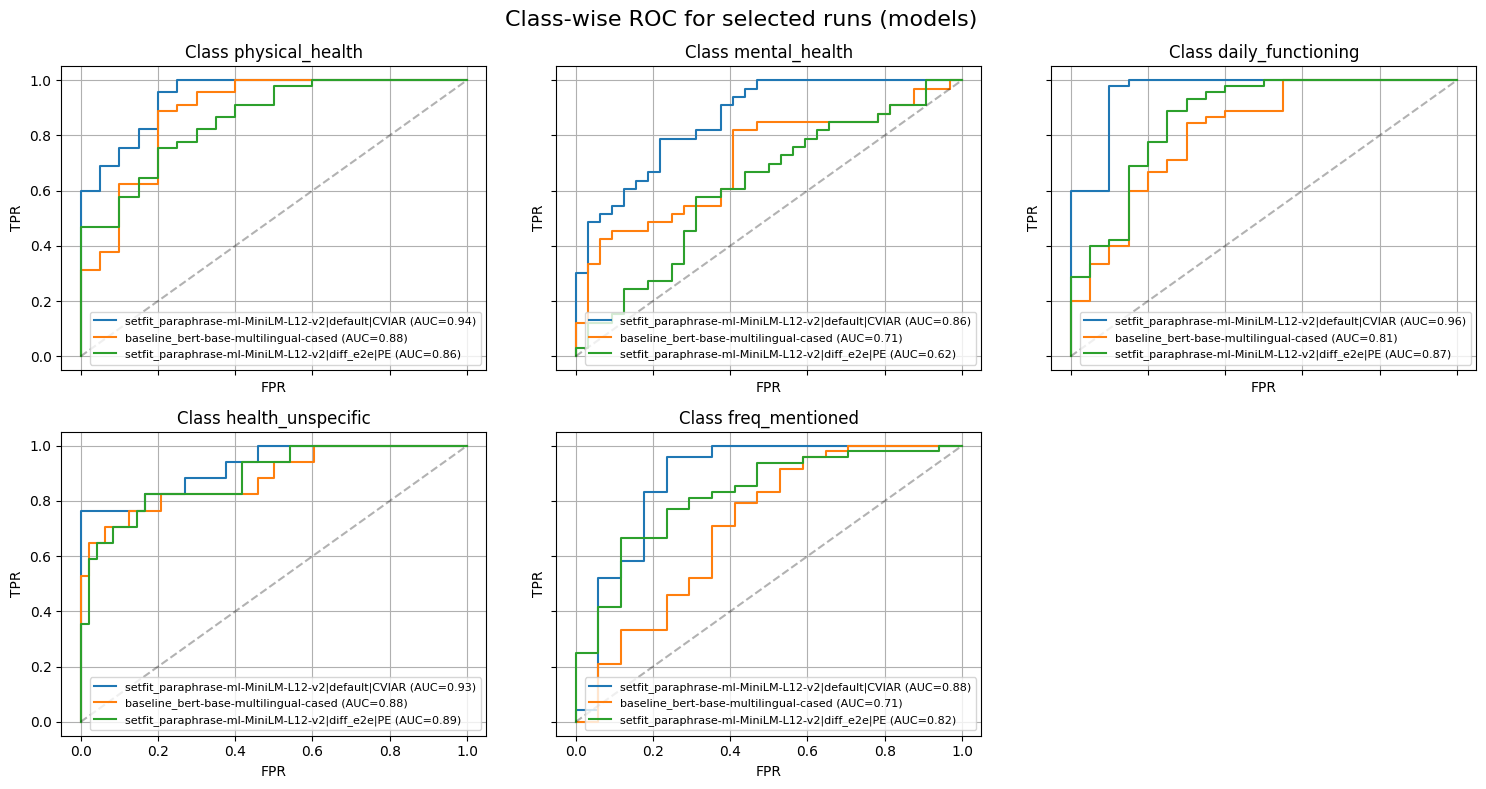

In [110]:
cols = 3
rows = math.ceil(len(class_ids) / cols)


fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, c in enumerate(class_ids):
    ax = axes[i]
    y_true_c = y_true_matrix[:, c]

    if y_true_c.sum() == 0:
        continue  # skip empty classes

    for run_id, y_score in y_scores_by_run.items():
        y_score_c = y_score[:, c]
        fpr, tpr, _ = roc_curve(y_true_c, y_score_c)
        roc_auc = auc(fpr, tpr)
        model_label = relevant_runs.loc[relevant_runs["run_id"] == run_id, "model_config"].values[0]
        ax.plot(fpr, tpr, label=f"{shorten_name(model_label)} (AUC={roc_auc:.2f})")

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(f"Class {code_pos_new.get(c, c)}")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.grid(True)
    ax.legend(fontsize=8, loc='lower right', frameon=True, framealpha=0.8)

# remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Class-wise ROC for selected runs (models)", fontsize=16)

plt.tight_layout()
plt.show()

## ROC curves for selected configurations per class with indicator estimation for threshold

Same but with marked threshold value (closest to 0.5).

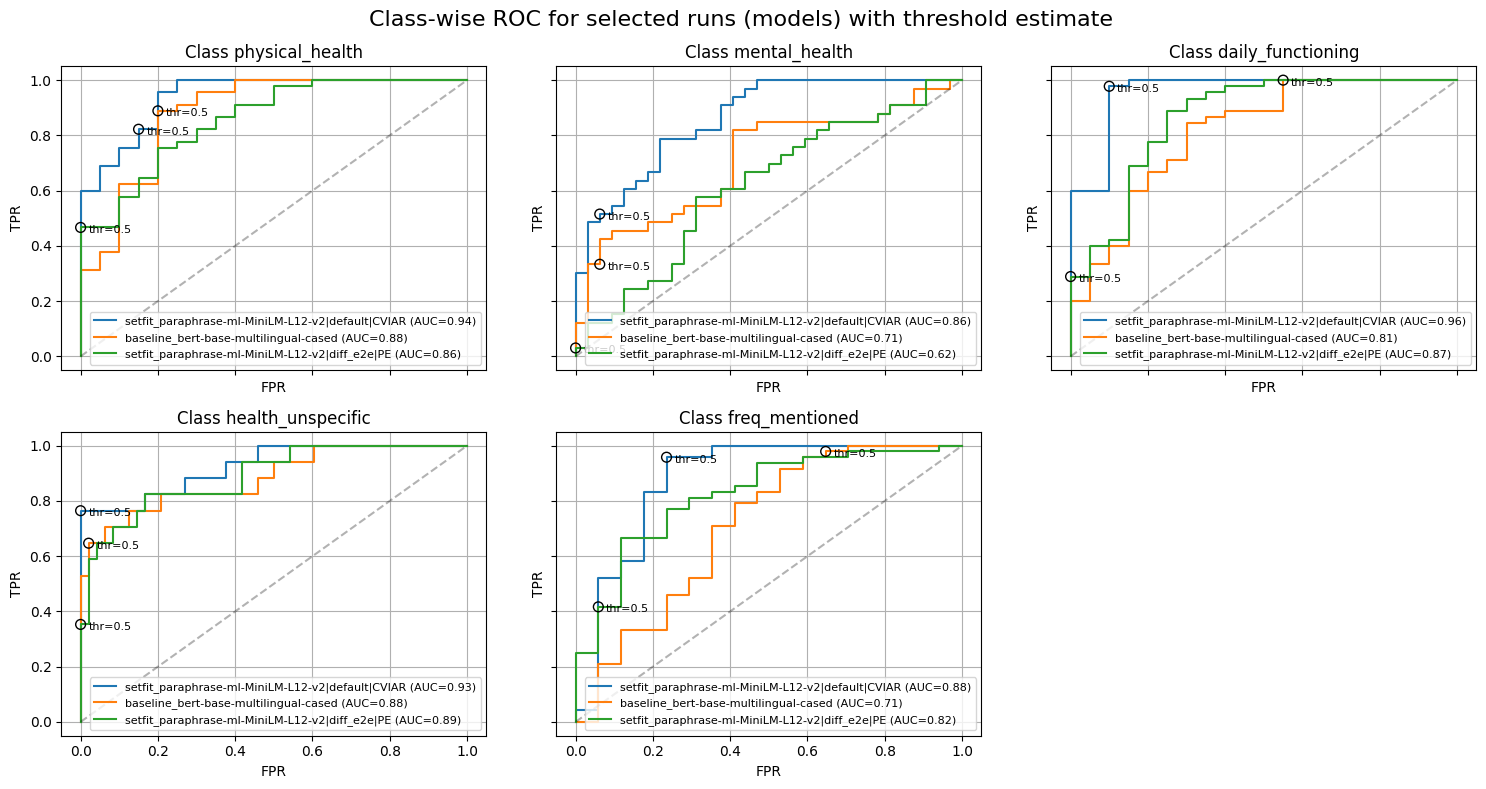

In [111]:
cols = 3
rows = math.ceil(len(class_ids) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), sharex=True, sharey=True)
axes = axes.flatten()

THRESHOLD_TO_MARK = 0.5 

for i, c in enumerate(class_ids):
    ax = axes[i]
    y_true_c = y_true_matrix[:, c]

    if y_true_c.sum() == 0:
        continue  # skip empty classes

    for run_id, y_score in y_scores_by_run.items():
        y_score_c = y_score[:, c]

        # Get FPR, TPR, and thresholds
        fpr, tpr, thresholds = roc_curve(y_true_c, y_score_c)
        roc_auc = auc(fpr, tpr)
        model_label = relevant_runs.loc[relevant_runs["run_id"] == run_id, "model_config"].values[0]
        ax.plot(fpr, tpr, label=f"{shorten_name(model_label)} (AUC={roc_auc:.2f})")

        # Annotate the point closest to threshold=0.5
        idx = (np.abs(thresholds - THRESHOLD_TO_MARK)).argmin()
        ax.scatter(fpr[idx], tpr[idx], s=50, edgecolors='k', facecolors='none', zorder=5)
        ax.text(fpr[idx]+0.02, tpr[idx]-0.02, f"thr={THRESHOLD_TO_MARK}", fontsize=8)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_title(f"Class {code_pos_new.get(c, c)}")
    ax.set_xlabel("FPR")
    ax.set_ylabel("TPR")
    ax.grid(True)
    ax.legend(fontsize=8, loc='lower right', frameon=True, framealpha=0.8)

# remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("Class-wise ROC for selected runs (models) with threshold estimate", fontsize=16)


plt.tight_layout()
plt.savefig("results/classwise_ROC_curve_selected models.png")
plt.show()

### Classwise Precision-Recall Curve

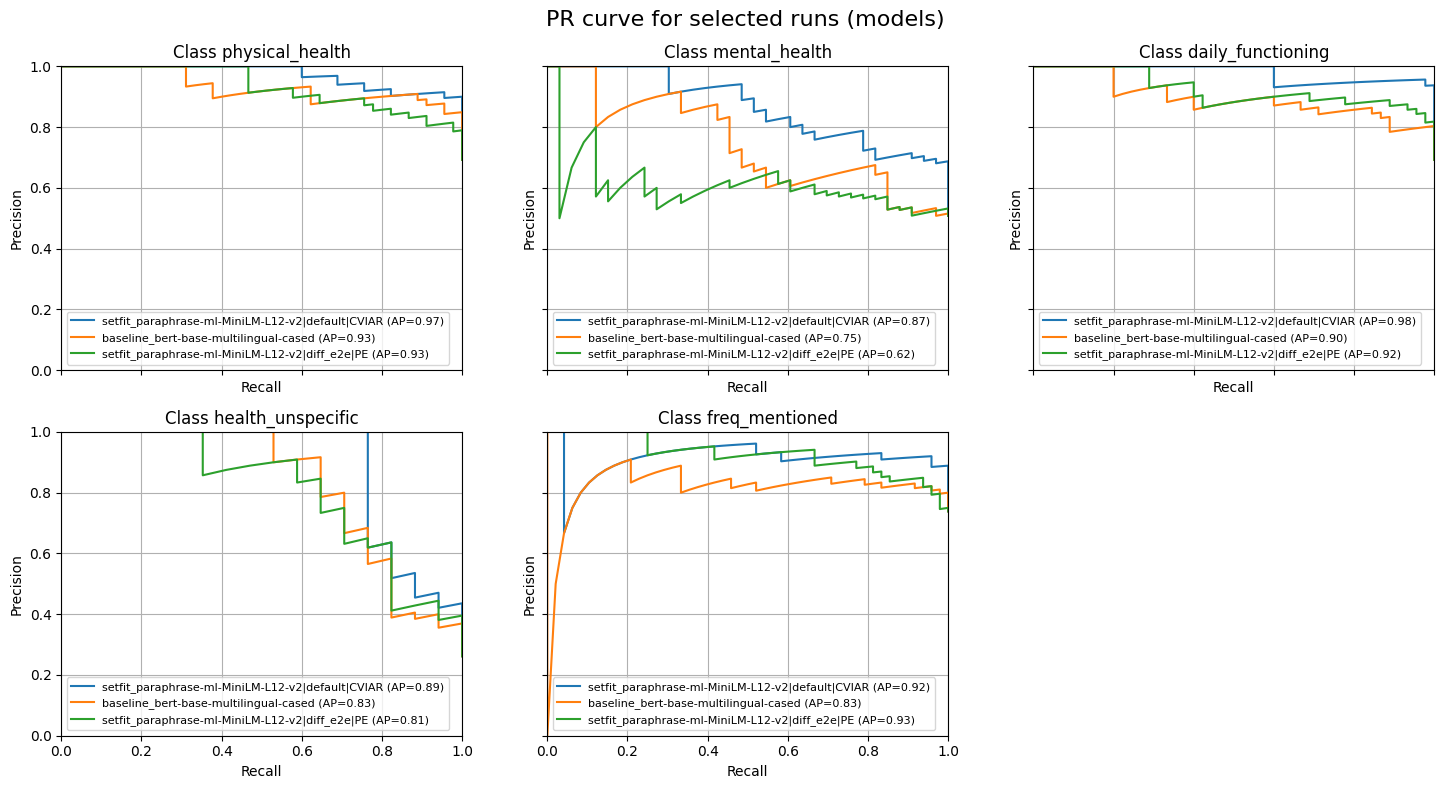

In [112]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score
import math

# Grid layout
cols = 3
rows = math.ceil(len(class_ids) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, c in enumerate(class_ids):
    ax = axes[i]
    y_true_c = y_true_matrix[:, c]

    if y_true_c.sum() == 0:
        continue  # skip classes with no positives

    for run_id, y_score in y_scores_by_run.items():
        y_score_c = y_score[:, c]

        # Precision-Recall curve
        precision, recall, thresholds = precision_recall_curve(y_true_c, y_score_c)
        ap = average_precision_score(y_true_c, y_score_c)  # average precision (area under PR curve)
        model_label = relevant_runs.loc[relevant_runs["run_id"] == run_id, "model_config"].values[0]
        
        # Plot PR curve
        ax.plot(recall, precision, label=f"{shorten_name(model_label)} (AP={ap:.2f})")
        
    ax.set_title(f"Class {code_pos_new.get(c, c)}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.grid(True)
    ax.legend(fontsize=8, loc='lower left', frameon=True, framealpha=0.8)

# remove empty subplots
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle("PR curve for selected runs (models)", fontsize=16)


plt.tight_layout()
plt.show()